In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

# Initialize visualization engine for SHAP
shap.initjs()

# Load saved model payload
payload = joblib.load('final_churn_xgb_model.pkl')
model = payload['model']
feature_names = payload['feature_names']

# Load baseline processed datasets
data_dict = joblib.load('processed_churn_data.pkl')
X_test = data_dict['X_test']
y_test = data_dict['y_test']

print("Saved model and validation datasets loaded successfully!")


c:\Users\swastik\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved model and validation datasets loaded successfully!


In [2]:
# TreeExplainer is ideal for XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print("SHAP values calculated across test dataset.")
print(f"SHAP values matrix shape: {shap_values.shape}")


SHAP values calculated across test dataset.
SHAP values matrix shape: (1409, 36)


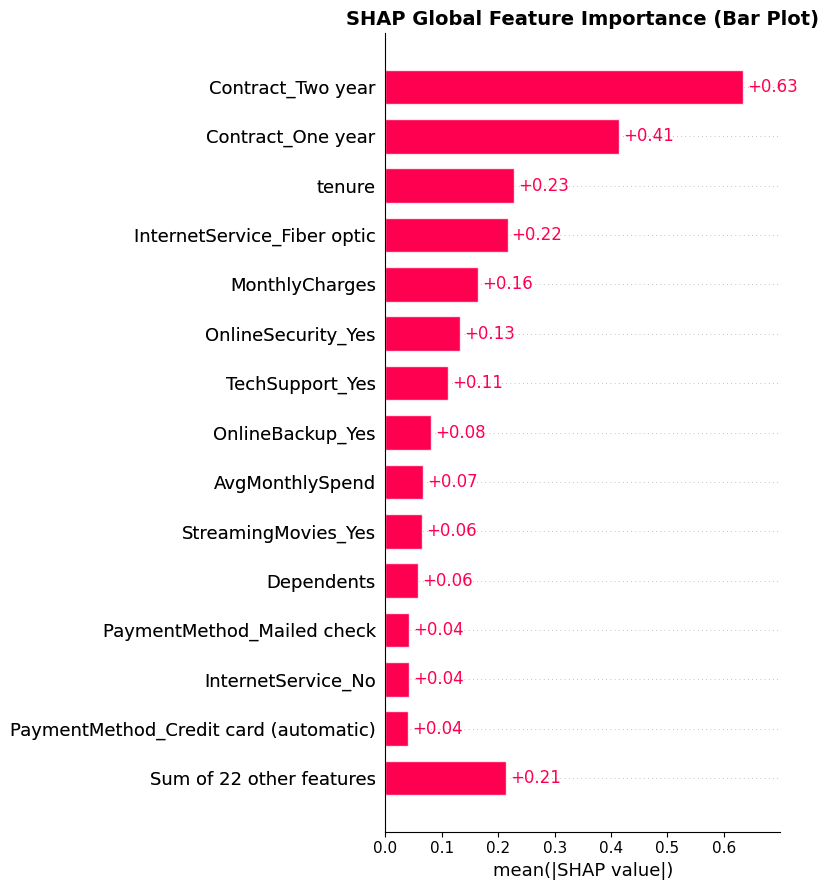

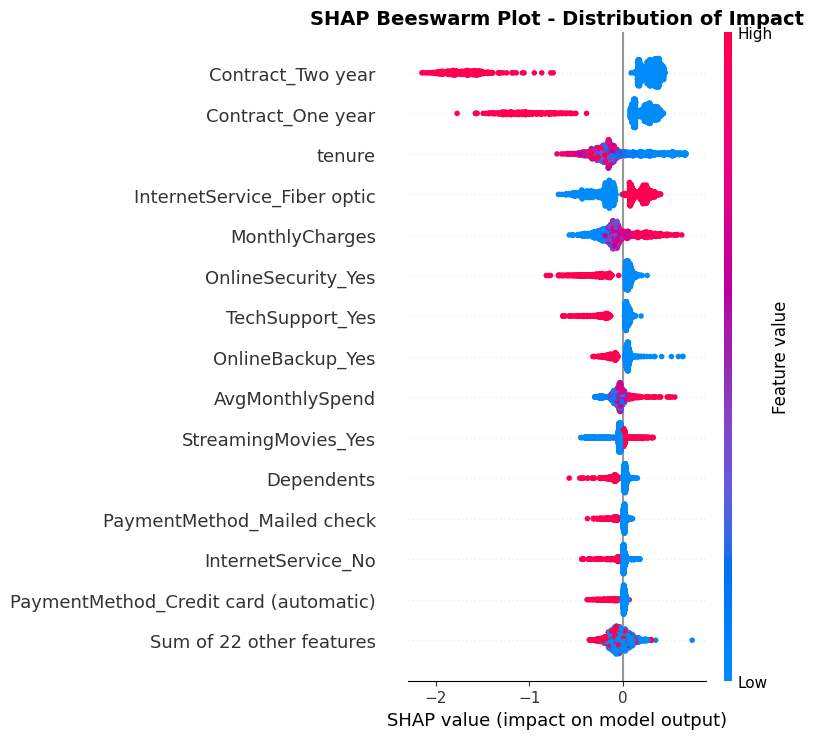

In [3]:
# Plot feature importance using bar plot
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP Global Feature Importance (Bar Plot)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot summary beeswarm plot (displays impact directionality)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm Plot - Distribution of Impact", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Selected High-Risk Index (Test row index): 29 (Churn Prob: 0.846)
Selected Low-Risk Index (Test row index): 0 (Churn Prob: 0.080)

Generating explanations for the high-risk customer...


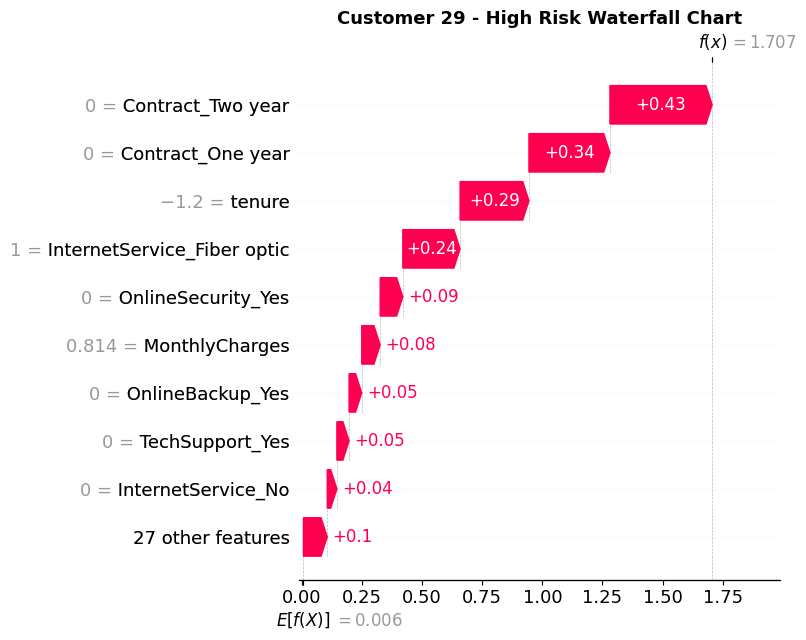


Generating explanations for the low-risk customer...


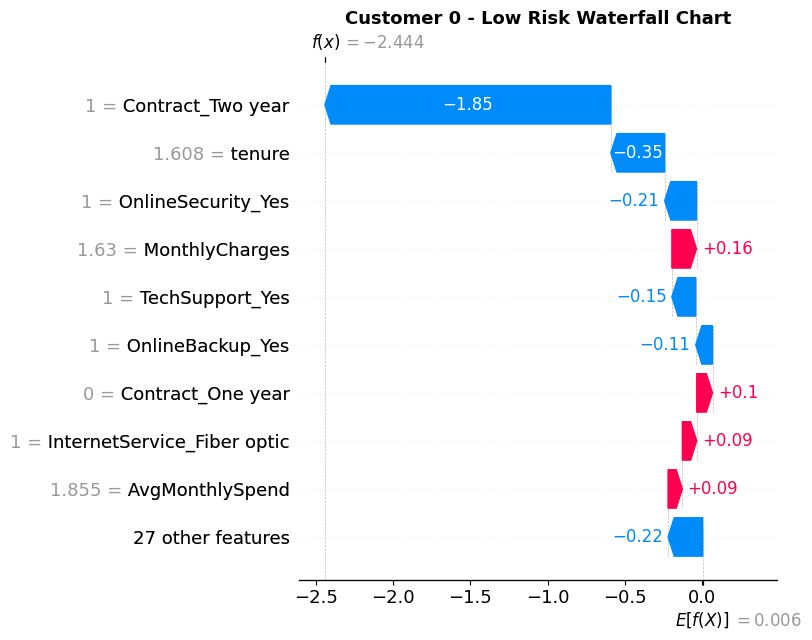

In [4]:
# Locate a high-probability churner (Churn probability > 0.8) and a low-probability churner in test set
test_probs = model.predict_proba(X_test)[:, 1]
high_risk_idx = np.where((test_probs > 0.8) & (y_test.values == 1))[0][0]
low_risk_idx = np.where((test_probs < 0.1) & (y_test.values == 0))[0][0]

print(f"Selected High-Risk Index (Test row index): {high_risk_idx} (Churn Prob: {test_probs[high_risk_idx]:.3f})")
print(f"Selected Low-Risk Index (Test row index): {low_risk_idx} (Churn Prob: {test_probs[low_risk_idx]:.3f})")

# High Risk Local Explanations
print("\nGenerating explanations for the high-risk customer...")
shap.plots.waterfall(shap_values[high_risk_idx], max_display=10, show=False)
plt.title(f"Customer {high_risk_idx} - High Risk Waterfall Chart", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Low Risk Local Explanations
print("\nGenerating explanations for the low-risk customer...")
shap.plots.waterfall(shap_values[low_risk_idx], max_display=10, show=False)
plt.title(f"Customer {low_risk_idx} - Low Risk Waterfall Chart", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Interactive Force Plot for High-Risk Customer:


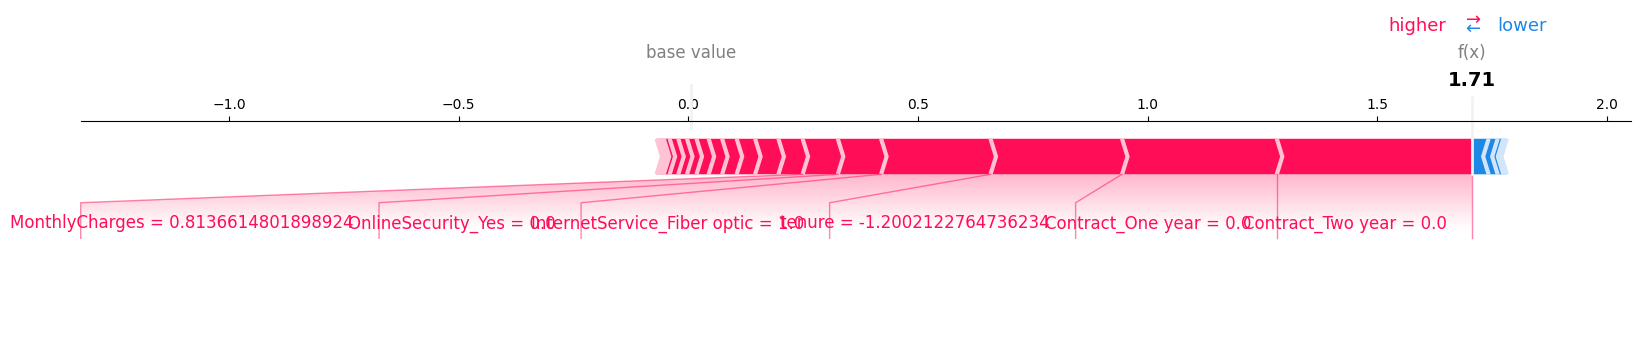

In [5]:
# Force Plot for the High-Risk Customer
# In Jupyter, this will render an interactive JavaScript widget
print("Interactive Force Plot for High-Risk Customer:")
shap.plots.force(explainer.expected_value, shap_values[high_risk_idx].values, X_test.iloc[high_risk_idx], matplotlib=True)


## SHAP Explanations Analysis

### 1. Top Positive Churn Drivers (Factors driving customers to leave)
* **Contract_One year / Contract_Two year (Absent):** Lacking long-term contracts (i.e., being on Month-to-Month) increases the probability of churn more than any other feature.
* **Monthly Charges:** High monthly bills represent a significant driver of customer attrition.
* **InternetService_Fiber optic:** Fiber optic subscribers are pushed significantly towards churn, reinforcing the bivariate analysis findings.
* **PaymentMethod_Electronic check:** Electronic check users are consistently linked with positive SHAP values.

### 2. Top Negative Churn Drivers (Factors keeping customers retained)
* **Tenure:** Higher tenure has a strong negative correlation with churn probability, showing that long-term relationships significantly insulate customers from leaving.
* **ServicesCount:** Customers utilizing multiple services (Online Security, Backup, etc.) display a negative shift in churn probability.
* **Contract_Two year:** Having a long-term agreement is the strongest anchor for customer retention.


## Recommended Retention Strategies Based on Explainable AI (XAI)

1. **Auto-Pay Migration Program:** Target Month-to-Month customers paying via Electronic Check with a small statement discount (e.g., $2/month) to transition them to Automatic Bank Transfer or Credit Card.
2. **Contract Conversion Campaign:** Implement high-value offers (e.g., "Get 2 Months Free") for Month-to-Month subscribers if they convert to a 12-month or 24-month contract.
3. **Fiber Optic Service Quality Review:** Investigate connectivity issues or cost structures within the fiber optic user base, as the technology itself is currently predicting higher churn probabilities.
4. **Service Bundling Discounts:** Bundle support features (`TechSupport` and `OnlineSecurity`) with standard subscriptions for new or high-risk customers, as higher service counts strongly correspond with lower churn rates.
5. **Early-Tenure Onboarding Journeys:** Create dedicated customer success pathways during the first 90 days of tenure, where the risk of early-stage churn is highest.
